In [2]:
import xarray as xr
import numpy as np
import imdlib as imd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import hvplot.xarray  # This adds the .hvplot accessor
import panel as pn
import holoviews as hv

In [3]:
imerg_combined = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_20150701_20240929.nc4")
start_yr = 2015
end_yr = 2024
variable = 'rain' # other options are ('tmin'/ 'tmax')
file_dir = "/Datastorage/saptarishi.dhanuka_asp25/imdlib_data/raw_imdlib"
data = imd.open_data(variable, start_yr, end_yr, 'yearwise', file_dir+'/rain/')
ds = data.get_xarray()
ds

<xarray.Dataset> Size: 509MB
Dimensions:  (time: 3653, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    rain     (time, lat, lon) float64 509MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-20 14:36:44.170137 Python
    references:   
    comment:      
    crs:          epsg:4326

In [4]:
imd_ds = ds.where(ds ['rain'] != -999.)
print(imd_ds)

<xarray.Dataset> Size: 509MB
Dimensions:  (time: 3653, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    rain     (time, lat, lon) float64 509MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-20 14:36:44.170137 Python
    references:   
    comment:      
    crs:          epsg:4326


In [5]:
print(imerg_combined)

<xarray.Dataset> Size: 4GB
Dimensions:        (time: 3367, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 27kB 2015-07-01 ... 2024-09-27
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 2GB ...
    randomError    (time, lon, lat) float64 2GB ...
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z


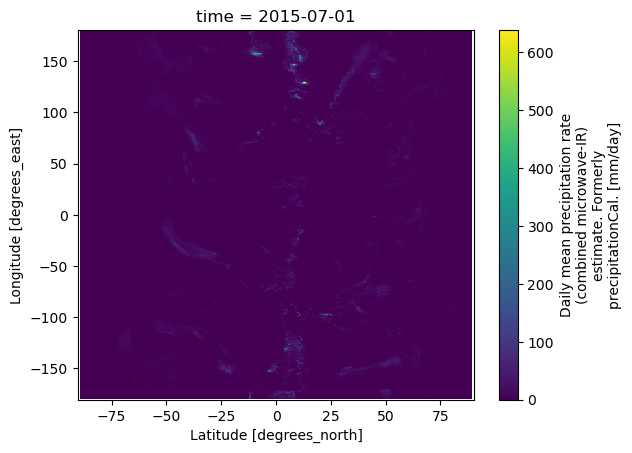

In [6]:
imerg_combined.isel(time=0)['precipitation'].plot()


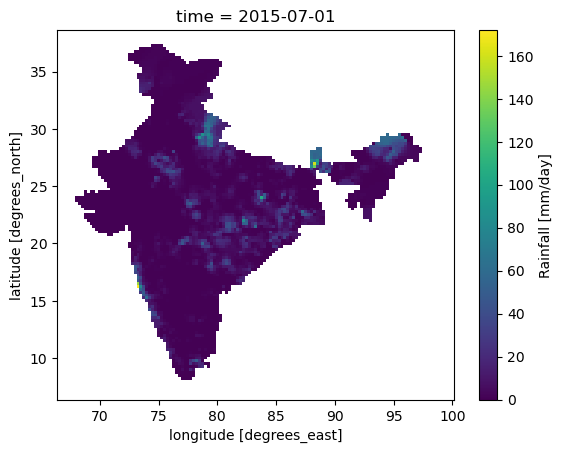

In [7]:
imd_ds['rain'].sel(time='2015-07-01').plot()

In [8]:
print("Step 2: Standardizing datasets...")

# Rename IMERG's variable to match IMD's 'rain'
imerg_standardized = imerg_combined.rename({'precipitation': 'rain'})

# Transpose IMERG to match IMD's dimension order (lat, lon) for clarity
imerg_standardized = imerg_standardized.transpose('time', 'lat', 'lon')

# --- 3. Align Datasets in Time and Space ---
# We'll find the overlapping time period and crop IMERG to IMD's spatial extent.

print("Step 3: Aligning datasets in time and space...")

# Find overlapping time range
common_time_start = max(imd_ds.time.min(), imerg_standardized.time.min())
common_time_end = min(imd_ds.time.max(), imerg_standardized.time.max())
common_time_start, common_time_end

Step 2: Standardizing datasets...
Step 3: Aligning datasets in time and space...


(<xarray.DataArray 'time' ()> Size: 8B
 array('2015-07-01T00:00:00.000000000', dtype='datetime64[ns]'),
 <xarray.DataArray 'time' ()> Size: 8B
 array('2024-09-27T00:00:00.000000000', dtype='datetime64[ns]'))

In [9]:

# Slice both datasets to the common time period
imd_aligned = imd_ds.sel(time=slice(common_time_start, common_time_end))


Step 4: Regridding IMERG data to the IMD grid...

Regridding Complete. Final shapes for comparison:
IMD Aligned Shape:   (3377, 129, 135)
IMERG Regridded Shape: (3377, 129, 135)

Step 5: Calculating Mean Squared Error (MSE)...

MSE Calculation Complete. Here are the first 5 values:
<xarray.DataArray 'rain' (time: 5)> Size: 40B
array([5.80881994, 4.59434165, 3.77625215, 4.25364317, 6.80460725])
Coordinates:
  * time     (time) datetime64[ns] 40B 2015-07-01 2015-07-02 ... 2015-07-05

Step 6: Visualizing the results...


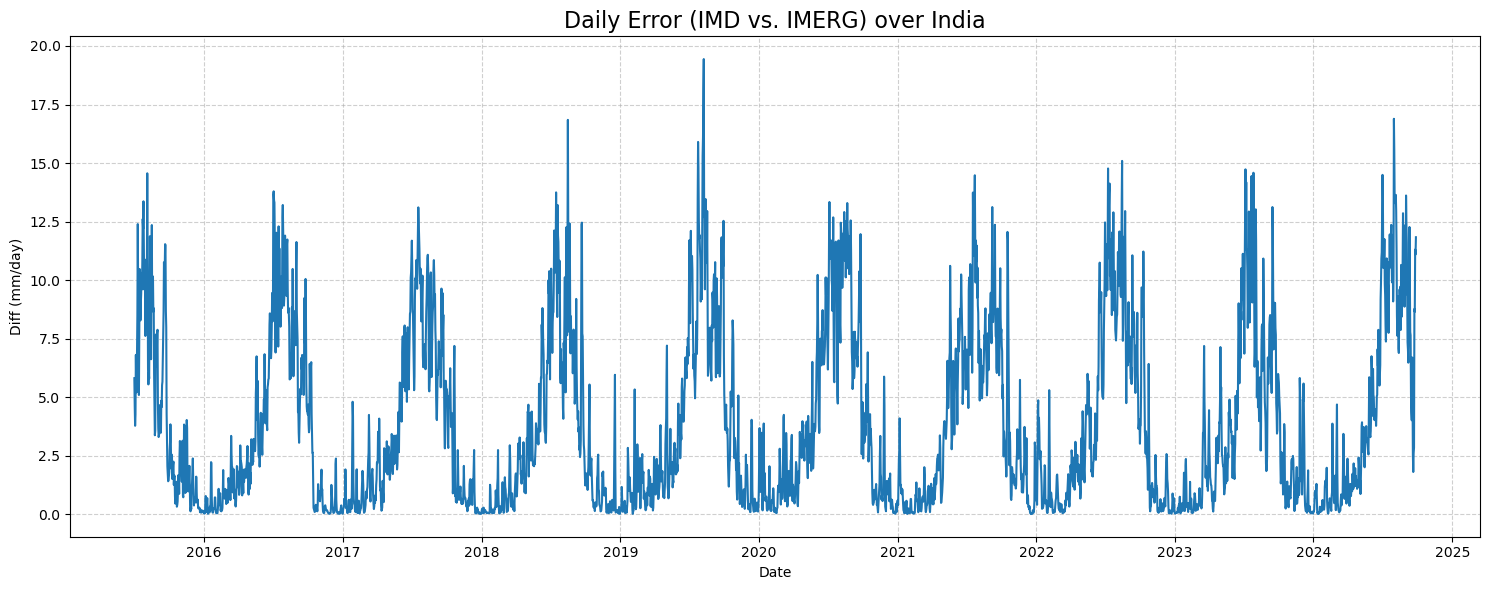

In [10]:

# Crop the global IMERG data to the spatial bounds of the IMD data
# This significantly reduces the amount of data to be regridded.
# Note: For decreasing lat coordinates, slice(max, min) is needed.
imerg_cropped = imerg_standardized.sel(
    time=slice(common_time_start, common_time_end),
    lat=slice(imd_aligned.lat.max().item(), imd_aligned.lat.min().item()),
    lon=slice(imd_aligned.lon.min().item(), imd_aligned.lon.max().item())
)

# --- 4. Regrid IMERG to the IMD Grid ---
# We will interpolate the IMERG data onto the exact lat/lon grid of the IMD data.
# This makes them directly comparable.

print("Step 4: Regridding IMERG data to the IMD grid...")

# Use xarray's powerful `interp_like` method. It handles all grid details.
imerg_regridded = imerg_cropped.interp_like(imd_aligned)

print("\nRegridding Complete. Final shapes for comparison:")
print(f"IMD Aligned Shape:   {imd_aligned.rain.shape}")
print(f"IMERG Regridded Shape: {imerg_regridded.rain.shape}")

# --- 5. Calculate Mean Squared Error (MSE) over India ---
# The core task: compare only where IMD has valid (non-NaN) data.

print("\nStep 5: Calculating Mean Squared Error (MSE)...")

# Create a mask where the IMD data is valid (i.e., over the Indian landmass)
# This is the key to fulfilling the requirement "compare values where the imd_ds has not null values"
land_mask = imd_aligned.rain.notnull()

# Apply the mask to both datasets. .where() keeps values where the mask is True,
# and sets them to NaN where it is False. This ensures we only compare grid cells over land.
imd_final = imd_aligned.where(land_mask)
imerg_final = imerg_regridded.where(land_mask)

# Calculate the difference
difference = imd_final['rain'] - imerg_final['rain']

# Square the difference
squared_difference = abs(difference)

# Calculate the Mean Squared Error for each timestep by averaging over the spatial dimensions
# The `skipna=True` is crucial as it correctly calculates the mean using only valid grid cells
mse_timeseries = squared_difference.mean(dim=['lat', 'lon'], skipna=True)

print("\nMSE Calculation Complete. Here are the first 5 values:")
print(mse_timeseries.head())


# --- 6. Visualize the Results ---

print("\nStep 6: Visualizing the results...")

# Plot the MSE time series
plt.figure(figsize=(15, 6))
mse_timeseries.plot()
plt.title('Daily Error (IMD vs. IMERG) over India', fontsize=16)
plt.ylabel('Diff (mm/day)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [11]:
# Crop the global IMERG data to the spatial bounds of the IMD data
# This significantly reduces the amount of data to be regridded.
# Note: For decreasing lat coordinates, slice(max, min) is needed.
imerg_cropped = imerg_standardized.sel(
    time=slice(common_time_start, common_time_end),
    lat=slice(imd_aligned.lat.max(), imd_aligned.lat.min()),
    lon=slice(imd_aligned.lon.min(), imd_aligned.lon.max())
)

# --- 4. Regrid IMERG to the IMD Grid ---
# We will interpolate the IMERG data onto the exact lat/lon grid of the IMD data.
# This makes them directly comparable.

print("Step 4: Regridding IMERG data to the IMD grid...")

# Use xarray's powerful `interp_like` method. It handles all grid details.
imerg_regridded = imerg_cropped.interp_like(imd_aligned)

print("\nRegridding Complete. Final shapes for comparison:")
print(f"IMD Aligned Shape:   {imd_aligned.rain.shape}")
print(f"IMERG Regridded Shape: {imerg_regridded.rain.shape}")

# --- 5. Calculate Mean Squared Error (MSE) over India ---
# The core task: compare only where IMD has valid (non-NaN) data.

print("\nStep 5: Calculating Mean Squared Error (MSE)...")

# Create a mask where the IMD data is valid (i.e., over the Indian landmass)
# This is the key to fulfilling the requirement "compare values where the imd_ds has not null values"
land_mask = imd_aligned.rain.notnull()

# Apply the mask to both datasets. .where() keeps values where the mask is True,
# and sets them to NaN where it is False. This ensures we only compare grid cells over land.
imd_final = imd_aligned.where(land_mask)
imerg_final = imerg_regridded.where(land_mask)

# Calculate the difference
difference = imd_final['rain'] - imerg_final['rain']

# Square the difference
squared_difference = difference

# Calculate the Mean Squared Error for each timestep by averaging over the spatial dimensions
# The `skipna=True` is crucial as it correctly calculates the mean using only valid grid cells
mse_timeseries = squared_difference.mean(dim=['lat', 'lon'], skipna=True)

print("\nMSE Calculation Complete. Here are the first 5 values:")
print(mse_timeseries.head())

Step 4: Regridding IMERG data to the IMD grid...

Regridding Complete. Final shapes for comparison:
IMD Aligned Shape:   (3377, 129, 135)
IMERG Regridded Shape: (3377, 129, 135)

Step 5: Calculating Mean Squared Error (MSE)...

MSE Calculation Complete. Here are the first 5 values:
<xarray.DataArray 'rain' (time: 5)> Size: 40B
array([ 1.29385516,  0.81222987,  1.52885938, -0.24711593, -2.8755464 ])
Coordinates:
  * time     (time) datetime64[ns] 40B 2015-07-01 2015-07-02 ... 2015-07-05


In [12]:
sample_date = mse_timeseries.time.dt.month.isin([7, 8]).argmax() # Find a day in July/Aug
sample_time_value = mse_timeseries.time[sample_date]
sample_time_value

<xarray.DataArray 'time' ()> Size: 8B
array('2015-07-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2015-07-01
Attributes:
    standard_name:  time
    long_name:      time

In [13]:
diff_sample_day = difference.sel(time=sample_time_value)

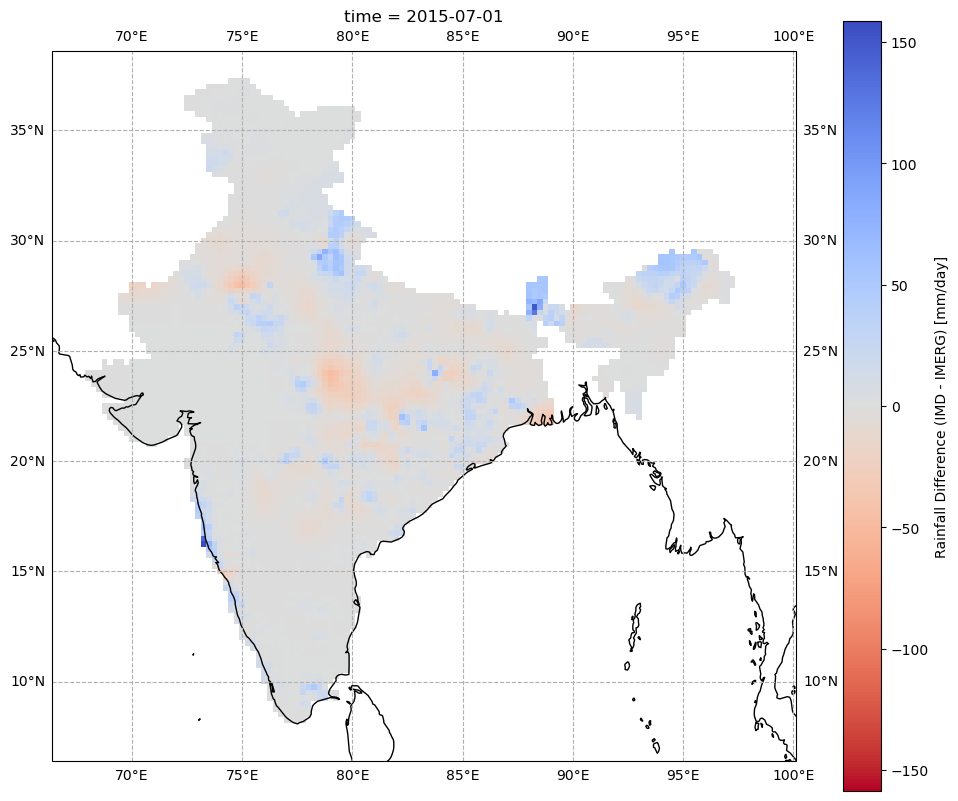

In [14]:

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
diff_sample_day.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm_r', # Diverging colormap
    cbar_kwargs={'label': 'Rainfall Difference (IMD - IMERG) [mm/day]'}
)
ax.coastlines()
ax.gridlines(draw_labels=True, linestyle='--')
# ax.set_title(f'Rainfall Difference on {pd.to_datetime(sample_time_value).strftime("%Y-%m-%d")}', fontsize=16)
plt.show()


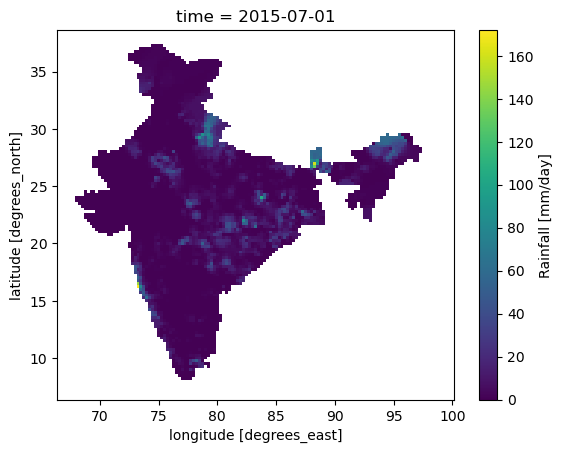

In [15]:
imd_final.sel(time=sample_time_value).rain.plot()

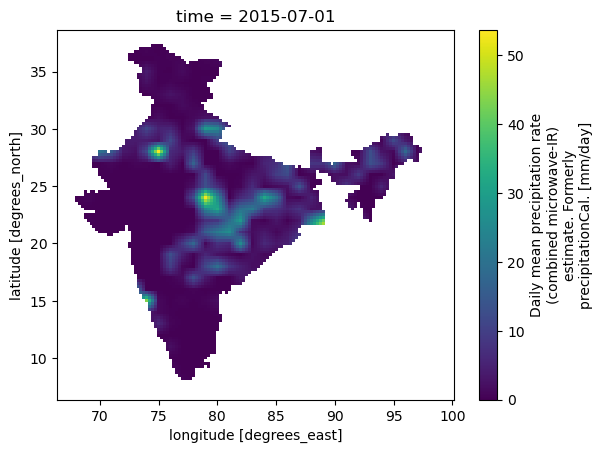

In [16]:
imerg_final.sel(time=sample_time_value).rain.plot()

In [17]:
pn.extension()

In [18]:
print("Step 1 & 2: Standardizing and Aligning datasets...")
# imerg_standardized = imerg_combined.rename({'precipitation': 'rain'}).transpose('time', 'lat', 'lon')
common_time_start = max(imd_ds.time.min(), imerg_standardized.time.min())
common_time_end = min(imd_ds.time.max(), imerg_standardized.time.max())
imd_aligned = imd_ds.sel(time=slice(common_time_start, common_time_end))
imerg_cropped = imerg_standardized.sel(
    time=slice(common_time_start, common_time_end),
    lat=slice(imd_aligned.lat.max().item(), imd_aligned.lat.min().item()),
    lon=slice(imd_aligned.lon.min().item(), imd_aligned.lon.max().item())
)

# --- 3. Regrid IMERG to the IMD Grid (Your Code) ---
print("Step 3: Regridding IMERG data...")
imerg_regridded = imerg_cropped.interp_like(imd_aligned)

# --- 4. Calculate Difference and MSE (Your Code) ---
print("Step 4: Calculating Difference and MSE...")
land_mask = imd_aligned.rain.notnull()
imd_final = imd_aligned.where(land_mask)
imerg_final = imerg_regridded.where(land_mask)
difference = (imd_final['rain'] - imerg_final['rain']).rename("Rainfall Difference (IMD - IMERG)")
squared_difference = abs(difference)
mse_timeseries = squared_difference.mean(dim=['lat', 'lon'], skipna=True).rename("MSE")

print("\nData preparation complete. Ready to build the interactive dashboard.\n")

Step 1 & 2: Standardizing and Aligning datasets...
Step 3: Regridding IMERG data...
Step 4: Calculating Difference and MSE...

Data preparation complete. Ready to build the interactive dashboard.



In [20]:
dashboard

NameError: name 'dashboard' is not defined

In [21]:
CLIM_RANGE = (-50, 50)

# Create the interactive map
# .hvplot() on a 3D DataArray with groupby='time' automatically creates a time slider.
# Create the interactive map
diff_map = difference.hvplot.quadmesh(
    x='lon',
    y='lat',
    rasterize=True,
    geo=True,
    tiles='OSM',
    crs=ccrs.PlateCarree(),
    cmap='coolwarm_r',
    clim=CLIM_RANGE,
    groupby='time',
    width=600,
    height=550,
    title="Daily Rainfall Difference (IMD - IMERG)",
    clabel='mm/day'
)

# Create the MSE time series line plot
mse_line = mse_timeseries.hvplot.line(
    x='time',
    y='MSE',
    height=250,
    width=850,
    grid=True,
    ylabel='Diff (mm/day)',
    title='Daily Error (IMD vs IMERG)'
)

# Create a dynamic marker linked to the map's widgets
def time_marker(time):
    mse_value = mse_timeseries.sel(time=time, method='nearest').item()
    return hv.Points(
        (time, mse_value),
        kdims=['time', 'MSE']
    ).opts(color='red', size=10, tools=['hover'])

# The kdims of the diff_map (which is a DynamicMap) contains the time widget we need to link to.
dynamic_marker = hv.DynamicMap(time_marker, kdims=diff_map.kdims)

# Overlay the line plot and the dynamic marker
final_line_plot = mse_line * dynamic_marker

# Arrange the map and the line plot into a dashboard using Panel
# CORRECTED LINE: Removed .cols(1) from diff_map
dashboard = pn.Column(
    "## IMD vs. IMERG Daily Rainfall Difference Explorer",
    "Use the **Time** slider or the play button to animate the daily difference map. The red dot on the line graph below indicates the corresponding Mean Squared Error for the selected day.",
    diff_map,  # This is the corrected line
    final_line_plot
)


In [22]:
dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'86d13ccc-c7d4-4ce0-a103-721537da678c': {'version…

In [ ]:
!pip install plotly

DEPRECATION: Loading egg at /home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/eccc_rpnpy-2.2.0rc3-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/fstd2nc-0.20240401.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 82.0 MB/s eta 0:00:00:00:0100:01


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import webbrowser
import os

In [ ]:
# --- 5. Build High-Performance Animation with Plotly (CORRECTED) ---
print("Step 5: Building Plotly animation...")

CLIM_MIN = -50
CLIM_MAX = 50

fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.7, 0.3],
    specs=[[{"type": "heatmap"}], [{"type": "xy"}]]
)

# Add traces (indices: 0=heatmap, 1=line, 2=dot)
fig.add_trace(go.Heatmap(z=diff_values[0, :, :], x=lons, y=lats, colorscale='RdBu_r', zmin=CLIM_MIN, zmax=CLIM_MAX, colorbar_title='Difference (mm/day)'), row=1, col=1)
fig.add_trace(go.Scatter(x=times, y=mse_values, mode='lines', name='MSE', line=dict(color='gray')), row=2, col=1)
fig.add_trace(go.Scatter(x=[times[0]], y=[mse_values[0]], mode='markers', name='Selected Day', marker=dict(color='red', size=10)), row=2, col=1)

# --- Create Animation Frames (CORRECTED LOGIC) ---
frames = []
for i, time in enumerate(times):
    frame = go.Frame(
        name=str(time),
        # The data array now only contains the traces that CHANGE.
        data=[
            go.Heatmap(z=diff_values[i, :, :]),       # New data for the heatmap
            go.Scatter(x=[times[i]], y=[mse_values[i]]) # New data for the marker
        ],
        # The 'traces' property maps the data above to the original traces by index.
        traces=[0, 2] # Apply data[0] to fig.data[0], and data[1] to fig.data[2].
    )
    frames.append(frame)

fig.frames = frames

# --- Create Slider and Buttons (No changes needed here) ---
def create_slider_steps(times):
    steps = []
    for i, time in enumerate(times):
        step = dict(
            method="animate",
            args=[
                [str(time)],
                {"frame": {"duration": 50, "redraw": True}, "mode": "immediate", "transition": {"duration": 0}}
            ],
            label=pd.to_datetime(time).strftime('%Y-%m-%d')
        )
        steps.append(step)
    return steps

play_button = dict(label="Play", method="animate", args=[None, {"frame": {"duration": 50, "redraw": True}, "fromcurrent": True, "transition": {"duration": 0}}])
pause_button = dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate", "transition": {"duration": 0}}])

# --- Update Figure Layout (No changes needed here) ---
fig.update_layout(
    title_text='Interactive Daily Rainfall Difference (IMD vs. IMERG)',
    height=800,
    yaxis=dict(title='Latitude', scaleanchor='x'),
    xaxis=dict(title='Longitude'),
    yaxis2=dict(title='MSE (mm/day)²'),
    xaxis2=dict(title='Date'),
    showlegend=False,
    sliders=[dict(steps=create_slider_steps(times), active=0, pad={"t": 50}, x=0.1, len=0.9)],
    updatemenus=[dict(type="buttons", showactive=False, buttons=[play_button, pause_button], direction="left", pad={"r": 10, "t": 70}, x=0.1, xanchor="right", y=0, yanchor="top")]
)

# --- Display using a local web server ---
print("\nStarting local web server...")
fig.show(notebook_handle=False) #, port=8050) # Uncomment and set port if needed

print("Connect to the animation by opening a web browser on your local machine and navigating to the address printed above.")